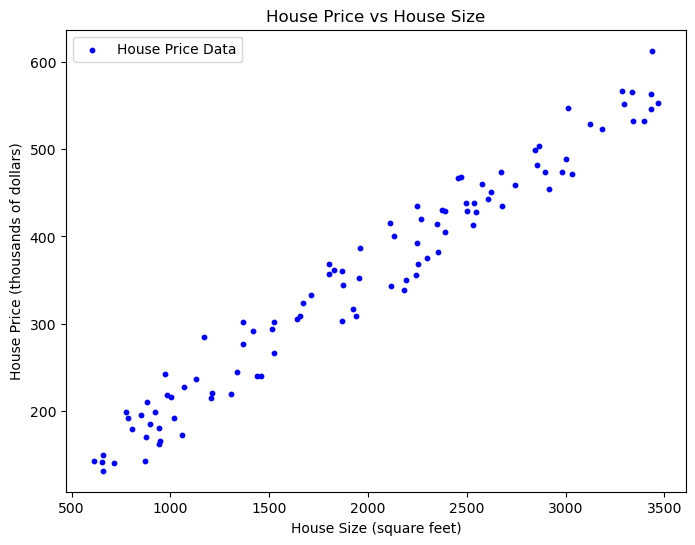

In [2]:
# Implementation using PyTorch
 
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
 
# Seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
 
# Generate synthetic dataset with 100 data points
# Predicting house prices based on house size
# x_data: house size in square feet
# y_data: house price in thousands of dollars
 
x_data = np.random.uniform(600, 3500, 100)
noise = np.random.normal(0, 25, 100)
 
# Price formula:
# price = 0.15 * house_size + 50 + noise
y_data = 0.15 * x_data + 50 + noise
 
# Convert to strict arrays for NumPy 2 compatibility
x_data = np.array(x_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.float32)
 
# Scale the input data for stable neural network training
x_data_scaled = (x_data - x_data.mean()) / x_data.std()
 
# Convert to PyTorch tensors and reshape
x_train = torch.from_numpy(x_data_scaled).view(-1, 1)
y_train = torch.from_numpy(y_data).view(-1, 1)
 
# Plot the original data
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, color="blue", s=10, label="House Price Data")
plt.xlabel("House Size (square feet)")
plt.ylabel("House Price (thousands of dollars)")
plt.title("House Price vs House Size")
plt.legend()
plt.show()


Sequential(
  (0): Linear(in_features=1, out_features=8, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=8, out_features=1, bias=True)
)
Epoch 200/2000, Loss: nan
Epoch 400/2000, Loss: nan
Epoch 600/2000, Loss: nan
Epoch 800/2000, Loss: nan
Epoch 1000/2000, Loss: nan
Epoch 1200/2000, Loss: nan
Epoch 1400/2000, Loss: nan
Epoch 1600/2000, Loss: nan
Epoch 1800/2000, Loss: nan
Epoch 2000/2000, Loss: nan


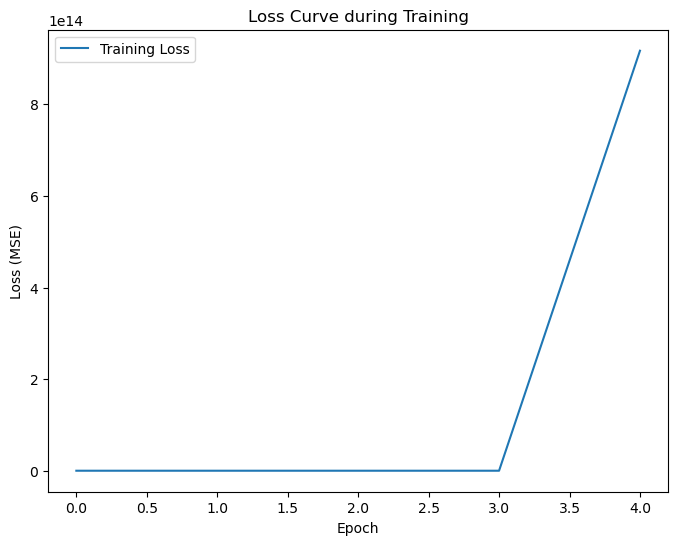

In [3]:
# Define the ANN regression model
model = nn.Sequential(
    nn.Linear(1, 8),
    nn.LeakyReLU(0.01),
    nn.Linear(8, 1)
)
 
print(model)
 
# Define the mean squared error loss function
criterion = nn.MSELoss()
 
# Define the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)
 
# Number of epochs
epochs = 2000
losses = []
 
# Training loop
for epoch in range(epochs):
 
    # Forward pass
    y_pred = model(x_train)
 
    # Compute loss
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())
 
    # Backward pass and parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")
 
# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(np.arange(epochs), np.array(losses, dtype=np.float32), label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve during Training")
plt.legend()
plt.show()


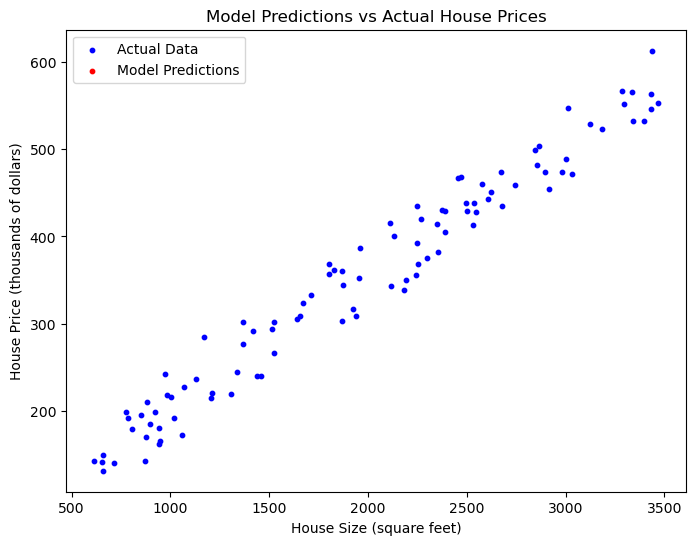

Final Correlation: nan


In [4]:
# Evaluate model predictions
with torch.no_grad():
    predictions = model(x_train)
 
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_data, color="blue", s=10, label="Actual Data")
plt.scatter(x_data, predictions.numpy(), color="red", s=10, label="Model Predictions")
plt.xlabel("House Size (square feet)")
plt.ylabel("House Price (thousands of dollars)")
plt.title("Model Predictions vs Actual House Prices")
plt.legend()
plt.show()
 
# Compute final correlation between predictions and actual data
actual = y_train.view(-1).numpy().astype(np.float64)
predicted = predictions.view(-1).numpy().astype(np.float64)
 
if np.std(predicted) == 0 or np.std(actual) == 0:
    correlation = float("nan")
    print("One of the inputs has zero variance. Correlation undefined.")
else:
    correlation_matrix = np.corrcoef(actual, predicted)
    correlation = correlation_matrix[0, 1]
    print(f"Final Correlation: {correlation:.4f}")
